In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F 
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Define a Residual Block
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

# Define the VAE model with convolutional layers and residual blocks
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        # Encoder
        self.enc_conv1 = ResidualBlock(1, 32, stride=1)
        self.enc_conv2 = ResidualBlock(32, 64, stride=2)
        self.enc_conv3 = ResidualBlock(64, 256, stride=2)
        self.enc_fc1 = nn.Linear(256 * 7 * 7, 128)
        self.enc_fc2_mu = nn.Linear(128, latent_dim)
        self.enc_fc2_logvar = nn.Linear(128, latent_dim)
        
        # Decoder
        self.dec_fc1 = nn.Linear(latent_dim, 128)
        self.dec_fc2 = nn.Linear(128, 64 * 7 * 7)
        self.dec_conv2 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)
        self.dec_conv3 = nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1)

    def encode(self, x):
        h = self.enc_conv1(x)
        h = self.enc_conv2(h)
        h = self.enc_conv3(h)
        h = h.view(-1, 256 * 7 * 7)
        h = F.relu(self.enc_fc1(h))
        return self.enc_fc2_mu(h), self.enc_fc2_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.dec_fc1(z))
        h = F.relu(self.dec_fc2(h))
        h = h.view(-1, 64, 7, 7)
        h = F.relu(self.dec_conv2(h))
        return self.dec_conv3(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [ ]:
# Define the loss function
def loss_function(recon_x, x, mu, logvar):
    MSE = F.mse_loss(recon_x, x, reduction='sum')
    print(mu.shape, logvar.shape)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return MSE + KLD

# Load MNIST dataset
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Training settings
epochs = 20
learning_rate = 1e-3

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

# Model, optimizer
latent_dim = 2  # Change this to the desired latent dimension
model = VAE(latent_dim=latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
model.train()
for epoch in range(epochs):
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        
        if batch_idx % 100 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} ({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item() / len(data):.6f}')
    
    print(f'====> Epoch: {epoch} Average loss: {train_loss / len(train_loader.dataset):.4f}')

# Save the model
torch.save(model.state_dict(), 'vae_model.pth')

# Load the model
model.load_state_dict(torch.load('vae_model.pth'))


Train Epoch: 0 [0/60000 (0%)]	Loss: 131.400070
Train Epoch: 0 [6400/60000 (11%)]	Loss: 52.854115
Train Epoch: 0 [12800/60000 (21%)]	Loss: 50.013680
Train Epoch: 0 [19200/60000 (32%)]	Loss: 50.863869
Train Epoch: 0 [25600/60000 (43%)]	Loss: 48.643715
Train Epoch: 0 [32000/60000 (53%)]	Loss: 47.721554
Train Epoch: 0 [38400/60000 (64%)]	Loss: 43.199429
Train Epoch: 0 [44800/60000 (75%)]	Loss: 41.489021
Train Epoch: 0 [51200/60000 (85%)]	Loss: 44.060234
Train Epoch: 0 [57600/60000 (96%)]	Loss: 43.166882
====> Epoch: 0 Average loss: 49.1870
Train Epoch: 1 [0/60000 (0%)]	Loss: 45.033184
Train Epoch: 1 [6400/60000 (11%)]	Loss: 44.822235
Train Epoch: 1 [12800/60000 (21%)]	Loss: 47.751667
Train Epoch: 1 [19200/60000 (32%)]	Loss: 43.444275
Train Epoch: 1 [25600/60000 (43%)]	Loss: 44.484798
Train Epoch: 1 [32000/60000 (53%)]	Loss: 42.262489
Train Epoch: 1 [38400/60000 (64%)]	Loss: 40.443928
Train Epoch: 1 [44800/60000 (75%)]	Loss: 39.757500
Train Epoch: 1 [51200/60000 (85%)]	Loss: 38.458824
Train

/tmp/ipykernel_3769339/1954530185.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('vae_model.pth'))


<All keys matched successfully>

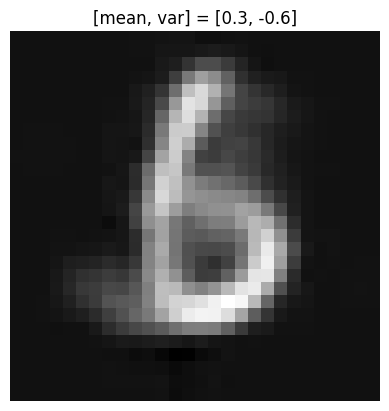

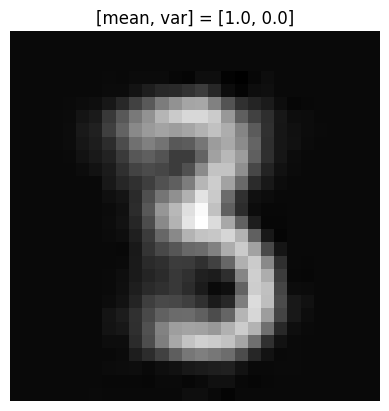

(None, None)

In [14]:
def generate_digit(mean, var):
    z_samplt = torch.tensor([[mean, var]], dtype=torch.float32).to(device)
    x_decoded = model.decode(z_samplt)
    x_decoded = x_decoded.detach().cpu().reshape(28, 28)
    plt.title(f'[mean, var] = [{mean}, {var}]')
    plt.imshow(x_decoded, cmap='gray')
    plt.axis('off')
    plt.show()

generate_digit(0.3, -0.6), generate_digit(1.0, 0.0)

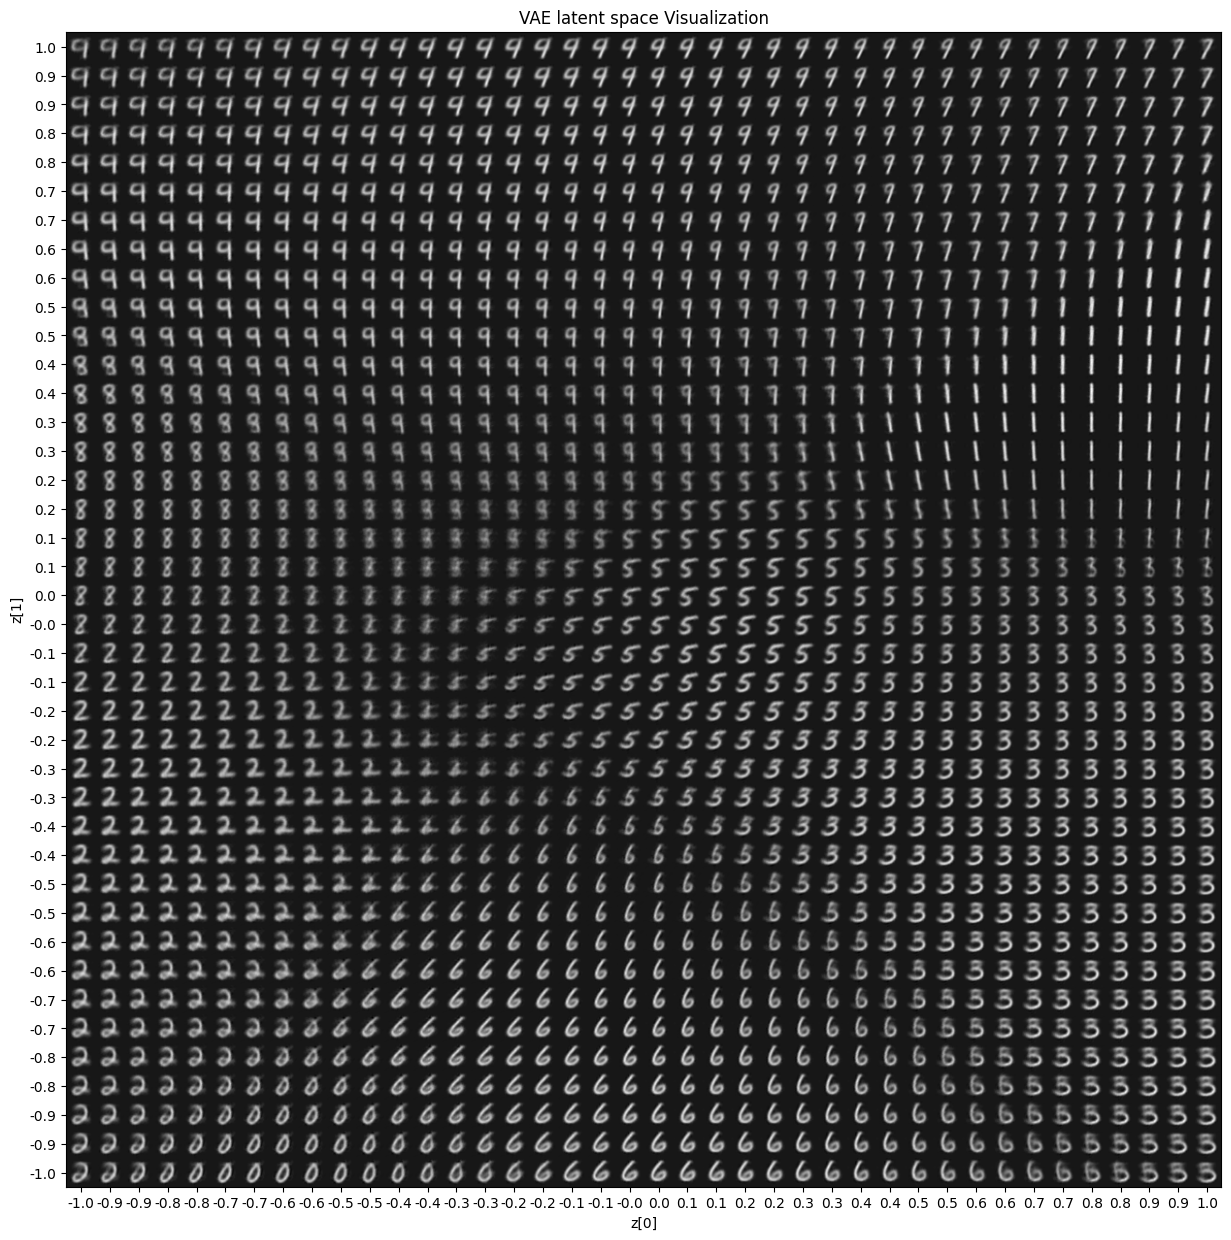

In [11]:
def plot_latent_space(model, scale=5.0, n=40, digit_size=28, figsize=15):
    figure = np.zeros((digit_size * n, digit_size * n))
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]
    
    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
            x_decoded = model.decode(z_sample)
            digit = x_decoded[0].reshape(digit_size, digit_size).detach().cpu().numpy()
            figure[i * digit_size: (i + 1) * digit_size, j * digit_size: (j + 1) * digit_size] = digit
    
    plt.figure(figsize=(figsize, figsize))
    plt.title('VAE latent space Visualization')
    start_range = digit_size // 2
    end_range = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    sample_range_x = np.round(grid_x, 1)
    sample_range_y = np.round(grid_y, 1)
    plt.xticks(pixel_range, sample_range_x)
    plt.yticks(pixel_range, sample_range_y)
    plt.xlabel('z[0]')
    plt.ylabel('z[1]')
    plt.imshow(figure, cmap='gray')
    plt.show()

plot_latent_space(model, scale=1.0)